In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5
import sys
from tqdm import tqdm 
sys.path.append('/home/cosweeney/code/Fits/')

from colossus.cosmology import cosmology
cosmo = cosmology.setCosmology('planck13')
a = 0.83760
redshift=1/a-1
H = cosmo.Hz(redshift)
h = cosmo.h
print(cosmo.h, cosmo.Hz(redshift), cosmo.H0*cosmo.Ez(redshift)) 

sys.path.append('/home/cosweeney/code/clive_bias')
sys.path.append('/home/cosweeney/code/GaussianStreamingModel')


from clive.models import *

import matplotlib
matplotlib.rcParams.update({'text.usetex': True, 
                            'font.family': 'Computer Modern Roman'})

from scipy.stats import gennorm, norm, t
import warnings
warnings.filterwarnings('ignore')

from scipy.optimize import curve_fit

import pandas as pd
import os

plt.rcParams['axes.labelsize'] = 20

0.6777 74.71913613009617 74.71913613009617


In [2]:
# define functions form GSM to compute RS tpcfs
from halotools.mock_observables import tpcf, s_mu_tpcf
from halotools.mock_observables import apply_zspace_distortion


def compute_real_tpcf(r, pos, boxsize, num_threads=1, pos_cross=None):
    """
        Computes the real space two point correlation function using halotools
        Args:
                r: np.array
                         binning in pair distances.
                pos: np.ndarray
                         3-D array with the position of the tracers.
                boxsize: float
                        size of the simulation's box.
                num_threads: int
                        number of threads to use.
                pos_cross: np.ndarray
                         3-D array with the position of the tracers
                         (for cross_correlations).

        Returns:
                real_tpcf: np.array
                        1-D array with the real space tpcf.
        """
    if pos_cross is not None:
        do_auto = False
    else:
        do_auto = True
    real_tpcf = tpcf(
        pos,
        r,
        period=boxsize,
        num_threads=num_threads,
        sample2=pos_cross,
        do_auto=do_auto,
    )
    return real_tpcf


def move_to_redshift_space(pos, vel, cosmology, redshift, los_direction, boxsize):
    s_pos = pos.copy()
    z_pos = apply_zspace_distortion(
        true_pos=pos[:, los_direction],
        peculiar_velocity=vel[:, los_direction],
        redshift=redshift,
        cosmology=cosmology,
        Lbox=boxsize,
    )
    # Move tracers to redshift space
    s_pos[:, los_direction] = z_pos
    # Halotools tpcf_s_mu assumes the line of sight is always the z direction
    if los_direction != 2:
        s_pos_old = s_pos.copy()
        s_pos[:, 2] = s_pos_old[:, los_direction]
        s_pos[:, los_direction] = s_pos_old[:, 2]
    return s_pos

def compute_tpcf_s_mu(
    s,
    mu,
    pos,
    vel,
    los_direction,
    cosmology,
    boxsize,
    redshift,
    num_threads=1,
    pos_cross=None,
    vel_cross=None,
):
    """
        Computes the redshift space two point correlation function
        Args:
                s: np.array
                        binning in redshift space pair distances.
                mu: np.array
                         binning in the cosine of the angle respect to the line of sight.
                pos: np.ndarray
                        3-D array with the position of the tracers, in Mpc/h.
                vel: np.ndarray
                         3-D array with the velocities of the tracers, in km/s.
                los_direction: int
                        line of sight direction either 0(=x), 1(=y), 2(=z)
                cosmology: dict
                        dictionary containing the simulatoin's cosmological parameters.
                boxsize:  float
                        size of the simulation's box.
                num_threads: int 
                        number of threads to use.
        Returns:
                tpcf_s_mu: np.ndarray
                        2-D array with the redshift space tpcf.
        """
    if pos_cross is not None:
        do_auto = False
    else:
        do_auto = True

    s_pos = move_to_redshift_space(
        pos, vel, cosmology, redshift, los_direction, boxsize
    )
    if pos_cross is not None and vel_cross is not None:
        s_pos_cross = move_to_redshift_space(
            pos_cross, vel_cross, cosmology, redshift, los_direction, boxsize
        )
    else:
        s_pos_cross = None
    tpcf_s_mu = s_mu_tpcf(
        s_pos,
        s,
        mu,
        period=boxsize,
        estimator=u"Landy-Szalay",
        num_threads=num_threads,
        sample2=s_pos_cross,
        do_auto=do_auto,
    )
    return tpcf_s_mu

In [3]:
from astropy.cosmology import Planck13

print(Planck13)
print(cosmo)

FlatLambdaCDM(name="Planck13", H0=67.77 km / (Mpc s), Om0=0.30712, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.048252)
Cosmology "planck13" 
    flat = True, Om0 = 0.3071, Ode0 = 0.6928, Ob0 = 0.0483, H0 = 67.77, sigma8 = 0.8288, ns = 0.9611
    de_model = lambda, relspecies = True, Tcmb0 = 2.7255, Neff = 3.0460, powerlaw = False


In [ ]:
# check how long to compute
import time

gsb_path = '/spiff/cosweeney/simulations/MDPL2/galaxies/SBp/'
gal_path = '/spiff/cosweeney/simulations/MDPL2/galaxies/UM_full_gal_table.hdf5'

box_length = 1000 #Mpc/h, MDPL2 box side length

#s, mu bins
mu_bins = np.linspace(0,1,120)
rbins = np.linspace(0.001, 80, 60)
rbins_c = 0.5*(rbins[1:] + rbins[:-1])



with h5.File(gal_path, 'r') as gcat:

    sm_cut = gcat['sm'][()] > 1e10

    gpos = np.array([
        gcat['pos'][:, 0][()][sm_cut],
        gcat['pos'][:, 1][()][sm_cut],
        gcat['pos'][:, 2][()][sm_cut],
    ]).T

    gvel = np.array([
        gcat['pos'][:, 3][()][sm_cut],
        gcat['pos'][:, 4][()][sm_cut], 
        gcat['pos'][:, 5][()][sm_cut],
    ]).T

    frac = 0.1
    idx = np.random.choice(len(gpos), int(frac * len(gpos)), replace=False)

    t0 = time.perf_counter()
    s_mu_tpcf = compute_tpcf_s_mu(
        s=rbins, 
        mu=mu_bins, 
        pos=gpos[idx], 
        vel=gvel[idx], 
        los_direction=2, 
        redshift=redshift,
        cosmology=Planck13, 
        boxsize=box_length,
        num_threads=84
    )
    t1 = time.perf_counter()

    # Rough upper bound: scales as N^2
    n_full, n_sub = len(gpos), len(idx)
    print(f"Subsample took {t1-t0:.1f}s → full estimate: ~{(t1-t0) * (n_full/n_sub)**2:.0f}s, or {(t1-t0) * (n_full/n_sub)**2 / 3600} hr")

Subsample took 20.4s → full estimate: ~2042s


In [5]:
2042 / 3600

0.5672222222222222

In [8]:
import os
print(os.cpu_count())

112


In [4]:
# compute and inspect the redshift space gg tpcf
gsb_path = '/spiff/cosweeney/simulations/MDPL2/galaxies/SBp/'
gal_path = '/spiff/cosweeney/simulations/MDPL2/galaxies/UM_full_gal_table.hdf5'

box_length = 1000 #Mpc/h, MDPL2 box side length

#s, mu bins
mu_bins = np.linspace(0,1,120)
rbins = np.linspace(0.001, 80, 60)


with h5.File(gal_path, 'r') as gcat:

    sm_cut = gcat['sm'][()] > 1e10

    gpos = np.array([
        gcat['pos'][:, 0][()][sm_cut],
        gcat['pos'][:, 1][()][sm_cut],
        gcat['pos'][:, 2][()][sm_cut],
    ]).T

    gvel = np.array([
        gcat['pos'][:, 3][()][sm_cut],
        gcat['pos'][:, 4][()][sm_cut], 
        gcat['pos'][:, 5][()][sm_cut],
    ]).T

    s_mu_tpcf = compute_tpcf_s_mu(
        s=rbins, 
        mu=mu_bins, 
        pos=gpos, 
        vel=gvel, 
        los_direction=2, 
        redshift=redshift,
        cosmology=Planck13, 
        boxsize=box_length,
        num_threads=84
    )

In [6]:
# save result 

save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/RSCFs/'

with h5.File(save_path+'xi_gg_s_mu_tpcf', 'a') as file:
    file.create_dataset(name='s_mu_tpcf', data=s_mu_tpcf, shape=s_mu_tpcf.shape, dtype=np.float64)
    file.create_dataset(name='sbins', data=rbins, shape=rbins.shape, dtype=np.float64)
    file.create_dataset(name='mu_bins', data=mu_bins, shape=mu_bins.shape, dtype=np.float64)

    file.attrs['redshift'] = redshift


In [4]:

box_length = 1000 #Mpc/h, MDPL2 box side length

#s, mu bins
mu_bins = np.linspace(0,1,120)
rbins = np.linspace(0.001, 80, 60)
rbins_c = 0.5*(rbins[1:] + rbins[:-1])


# load result
save_path = '/spiffball/cosweeney/simulations/MDPL2/data/CorrFuncs/RSCFs/'


tpcf_file = h5.File(save_path+'xi_gg_s_mu_tpcf', 'r')

s_mu_tpcf = tpcf_file['s_mu_tpcf'][()]

In [5]:
from halotools.mock_observables import tpcf_multipole

monopole = tpcf_multipole(
    s_mu_tpcf, 
    mu_bins, 
    order=0
)
quadrupole = tpcf_multipole(
    s_mu_tpcf, 
    mu_bins, 
    order=2
)
hexadecapole = tpcf_multipole(
    s_mu_tpcf, 
    mu_bins, order=4)

In [6]:
# load in real-space \xi_gg
xi_path = '/spiff/cosweeney/simulations/MDPL2/data/CorrFuncs/xi_gg.hdf5'

hdf = h5.File(xi_path, 'r')

xigg = hdf['xi'][()]
xigg_cov = hdf['xi_cov'][()]

r_cens = hdf['r_cens'][()] 
r_edges = hdf['r_edges'][()] 

# interpolate over same bins
xigg_interp_fcn = interp1d(r_cens, xigg, 'cubic', bounds_error=None, fill_value=0.0)
xigg_interp = interp1d(r_cens, xigg, 'cubic', bounds_error=None, fill_value=0.0)(rbins_c)

Text(0.5, 1.0, 'MDPL2 True Redshift-space $\\xi_{\\rm gg}(s, \\mu)$')

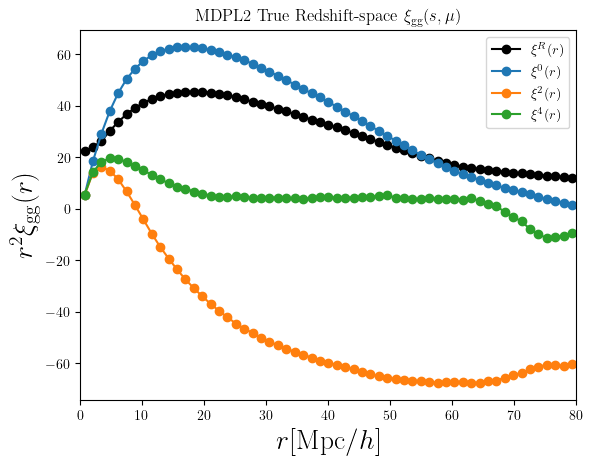

In [7]:

plt.plot(rbins_c, rbins_c**2*xigg_interp,
        label=r'$\xi^R(r)$', marker='o', c='k')
plt.plot(rbins_c, rbins_c**2*monopole,
        label=r'$\xi^0(r)$', marker='o')
plt.plot(rbins_c, rbins_c**2*quadrupole,
        label=r'$\xi^2(r)$', marker='o')
plt.plot(rbins_c, rbins_c**2*hexadecapole,
        label=r'$\xi^4(r)$', marker='o')
plt.legend()
plt.ylabel(r'$r^2\xi_{\rm gg}(r)$')
plt.xlabel(r'$r [\mathrm{Mpc}/h]$')

plt.xlim((0, 80))

plt.title(r'MDPL2 True Redshift-space $\xi_{\rm gg}(s, \mu)$')

In [8]:
# note: need to marginalize over masses to get P(v|r) instead of P(v|r, M) (see Robertson et al 2024, Sec. 7.1.3)

# compute # of halos in each mass bin
halo_path = '/spiff/cosweeney/simulations/MDPL2/hlists/hlist_0.83760_update.hdf5'

mbins2 = np.logspace(np.log10(1e12), np.log10(1e15), 30+1)

N_halos = np.zeros(len(mbins2)-1)
with h5.File(halo_path, 'r') as hcat:
    for k in range(len(mbins2)-1):
        mcut = (hcat['mvir'] > mbins2[k]) & (hcat['mvir'] <= mbins2[k+1])

        N_bin = mcut.sum()

        N_halos[k] = N_bin

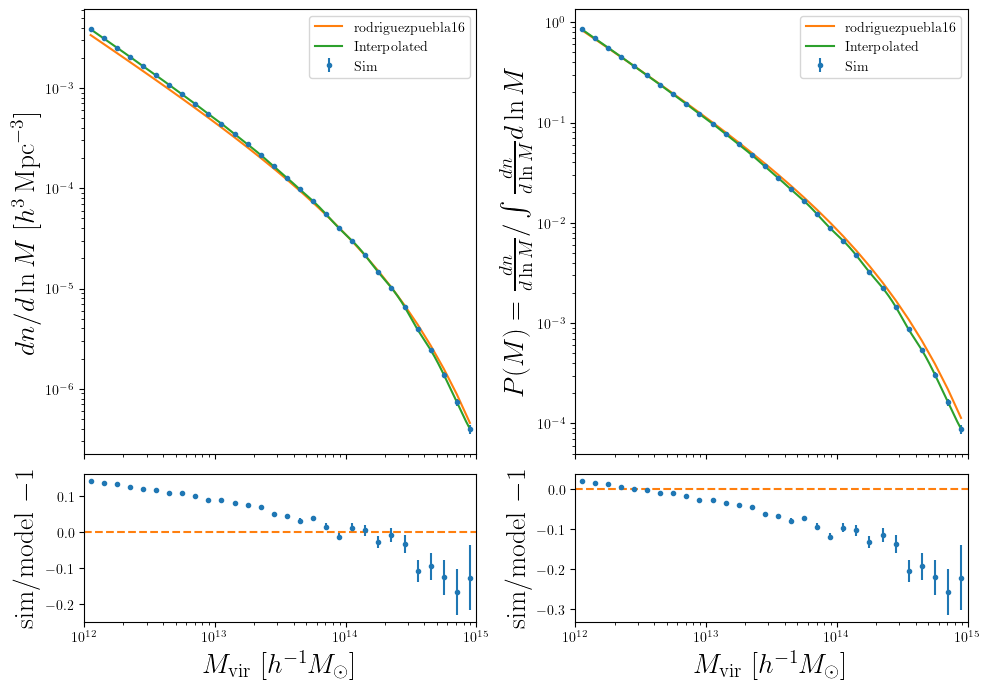

In [29]:
from colossus.lss import mass_function

Lbox = 1_000
Vbox = Lbox**3

dlnM = np.diff(np.log(mbins2))
mcens = (mbins2[1:] * mbins2[:-1])**0.5

dndlnM_sim = N_halos / (Vbox * dlnM)
sigma_dndlnM = np.sqrt(N_halos) / (Vbox * dlnM)

mfunc = mass_function.massFunction(mcens, redshift, mdef='vir', model='rodriguezpuebla16', q_out='dndlnM')

Norm        = np.sum(dndlnM_sim * dlnM)
P_sim       = dndlnM_sim / Norm
P_pred      = mfunc / np.sum(mfunc * dlnM)
sigma_P     = sigma_dndlnM / Norm

resid_hmf       = dndlnM_sim / mfunc - 1
sigma_resid_hmf = sigma_dndlnM / mfunc

resid_P       = P_sim / P_pred - 1
sigma_resid_P = sigma_P / P_pred

fig, axes = plt.subplots(2, 2, figsize=(10, 7),
                         gridspec_kw={'height_ratios': [3, 1]},
                         sharex='col')

axes[0, 0].errorbar(mcens, dndlnM_sim, yerr=sigma_dndlnM, fmt='.', color='C0', label='Sim')
axes[0, 0].plot(mcens, mfunc, c='C1', label='rodriguezpuebla16')
axes[0, 0].set(yscale='log', xscale='log', ylabel=r'$dn/d\ln M\ [h^3\,\mathrm{Mpc}^{-3}]$')
axes[0, 0].legend()
axes[0, 0].set_xlim((np.min(mbins2), np.max(mbins2)))

axes[0, 1].errorbar(mcens, P_sim, yerr=sigma_P, fmt='.', color='C0', label='Sim')
axes[0, 1].plot(mcens, P_pred, c='C1', label='rodriguezpuebla16')
axes[0, 1].set(yscale='log', xscale='log', ylabel=r'$P(M)=\frac{dn}{d\ln M}/\int \frac{dn}{d\ln M} d\ln M$')
axes[0, 1].legend()
axes[0, 1].set_xlim((np.min(mbins2), np.max(mbins2)))

axes[1, 0].errorbar(mcens, resid_hmf, yerr=sigma_resid_hmf, fmt='.', color='C0')
axes[1, 0].axhline(0, c='C1', ls='--')
axes[1, 0].set(xscale='log', xlabel=r'$M_\mathrm{vir}\ [h^{-1}M_\odot]$', ylabel=r'sim/model $-1$')
axes[1, 0].set_xlim((np.min(mbins2), np.max(mbins2)))

axes[1, 1].errorbar(mcens, resid_P, yerr=sigma_resid_P, fmt='.', color='C0')
axes[1, 1].axhline(0, c='C1', ls='--')
axes[1, 1].set(xscale='log', xlabel=r'$M_\mathrm{vir}\ [h^{-1}M_\odot]$', ylabel=r'sim/model $-1$')
axes[1, 1].set_xlim((np.min(mbins2), np.max(mbins2)))

plt.tight_layout()


from scipy.interpolate import interp1d

m_fine  = np.logspace(np.log10(mcens[0]), np.log10(mcens[-1]), 300)
lm      = np.log(mcens)
lm_fine = np.log(m_fine)

interp_hmf = interp1d(lm, np.log(dndlnM_sim), kind='cubic')
interp_P   = interp1d(lm, np.log(P_sim),       kind='cubic')

axes[0, 0].plot(m_fine, np.exp(interp_hmf(lm_fine)), c='C2', label='Interpolated')
axes[0, 1].plot(m_fine, np.exp(interp_P(lm_fine)),   c='C2', label='Interpolated')

axes[0, 0].legend()
axes[0, 1].legend()

In [21]:
from scipy.integrate import quad, simpson

def Pv_margM(v, R, rlos):
        
    Lbox = 1_000
    Vbox = Lbox**3

    dlnM = np.diff(np.log(mbins2))
    mcens = (mbins2[1:] * mbins2[:-1])**0.5

    mfunc = mass_function.massFunction(mcens, redshift, mdef='vir', model='rodriguezpuebla16', q_out='dndlnM')

    P_pred      = mfunc / np.sum(mfunc * dlnM)

    Pv = np.array([Pv_R_rlos(v, R, rlos, m) for m in mcens])

    dist = np.sum( P_pred[:, None] * Pv * (mcens*dlnM)[:, None], axis=0)

    return  dist /np.sum(dist*np.diff(v)[0])


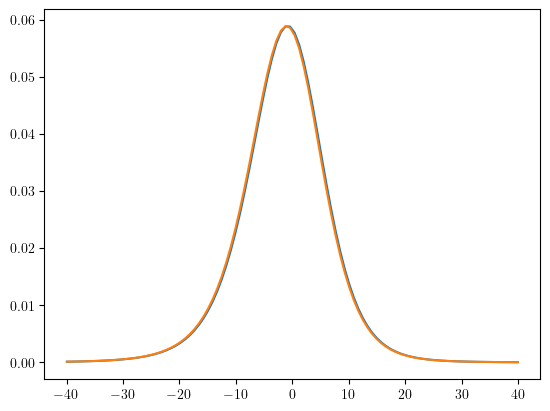

In [35]:
vcens = np.linspace(-2500, 2500, 100)

R_test = 10
rlos_test = 50

test = Pv_margM_vec(vcens, R_test, rlos_test)
test2 = Pv_R_rlos(vcens, R_test, rlos_test, np.mean(mbins2))

plt.plot(vcens/a/H, test)
plt.plot(vcens/a/H, a*H*test2)

In [24]:
test = np.array([Pv_R_rlos(np.linspace(-1000, 1000, 100), 10, 100, m) for m in mcens])
(test*P_pred[:, None]).shape

(30, 100)

In [21]:
P_pred.shape

(30,)

In [44]:
# great! next up: use the best-fit comapct P(v|r) model and the rstpcf to see what our predictions look like!
from typing import Callable
from scipy.integrate import simpson#, quadrature, quad


def integrand_s_mu(
    s_c: float, mu_c: float, twopcf_function: Callable, los_pdf_function: Callable
):
    """
    Computes the streaming model integrand ( https://arxiv.org/abs/1710.09379, Eq 22 ) at s, mu
    Args:
        s_c: bin centers for the pair distance bins.
        mu_c: bin centers for the cosine of the angle rescpect to the line of sight bins.
        twopcf_function: function that given pair distance as an argument returns the real space two point 
                correlation function.
        los_pdf_function: given the line of sight velocity, perpendicular and parallel distances to the line
                of sight, returns the value of the line of sight pairwise velocity distribution.
    Returns:
        integrand: np.ndarray
            2-D array with the value of the integrand evaluated at the given s_c and mu_c.			
	"""

    def integrand(y):
        S = s_c.reshape(-1, 1)
        MU = mu_c.reshape(1, -1)
        s_parallel = S * MU
        s_perp = S * np.sqrt(1 - MU ** 2)
        # Use reshape to vectorize all possible combinations
        s_perp = s_perp.reshape(-1, 1)
        s_parallel = s_parallel.reshape(-1, 1)
        y = y.reshape(1, -1)
        vlos = (s_parallel - y) * np.sign(y)
        r = np.sqrt(s_perp ** 2 + y ** 2)
        los_pdf = np.nan_to_num(los_pdf_function(vlos, s_perp, y), #np.abs(y)
                copy=False)
        return los_pdf * (1 + twopcf_function(r.flatten()).reshape(r.shape))

    return integrand


def simps_integrate(
    s_c: np.array,
    mu_c: np.array,
    twopcf_function: Callable,
    los_pdf_function: Callable,
    limit: float = 120.0,
    epsilon: float = 0.0001,
    n: int = 300,
):
    """
    Computes the streaming model integral ( https://arxiv.org/abs/1710.09379, Eq 22 ) 
    Args:
        s_c: pair distance bins.
        mu_c: cosine of the angle rescpect to the line of sight bins.
        twopcf_function: function that given pair distance as an argument returns the real space two point 
                correlation function.
        los_pdf_function: given the line of sight velocity, perpendicular and parallel distances to the line
                of sight, returns the value of the line of sight pairwise velocity distribution.
        limit: r_parallel limits of the integral.
        epsilon: due to discontinuity at zero, add small offset +-epsilon to estimate integral.
        n: number of points to evaluate the integrand.
    Returns:
        twopcf_s: np.ndarray
            2-D array with the resulting redshift space two point correlation function
	"""

    streaming_integrand = integrand_s_mu(s_c, mu_c, twopcf_function, los_pdf_function)
    # split integrand in two due to discontinuity at 0
    r_integrand = np.linspace(-limit, -epsilon, n)
    integral_left = simpson(
        streaming_integrand(r_integrand), r_integrand, axis=-1
    ).reshape((s_c.shape[0], mu_c.shape[0]))

    r_integrand = np.linspace(epsilon, limit, n)
    integral_right = simpson(
        streaming_integrand(r_integrand), r_integrand, axis=-1
    ).reshape((s_c.shape[0], mu_c.shape[0]))

    twopcf_s = integral_left + integral_right - 1.0
    return twopcf_s

In [45]:
def Pv_margM_vec(v, R, rlos):
    dlnM  = np.diff(np.log(mbins2))
    mcens = (mbins2[1:] * mbins2[:-1])**0.5

    mfunc  = mass_function.massFunction(mcens, redshift, mdef='vir', model='rodriguezpuebla16', q_out='dndlnM')
    P_pred = mfunc / np.sum(mfunc * dlnM)

    input_shape = np.broadcast_shapes(np.shape(v), np.shape(R), np.shape(rlos))
    nd = len(input_shape)

    v_b    = np.broadcast_to(v,    input_shape)[None]   # (1, *input_shape)
    R_b    = np.broadcast_to(R,    input_shape)[None]   # (1, *input_shape)
    rlos_b = np.broadcast_to(rlos, input_shape)[None]   # (1, *input_shape)
    M_b    = mcens.reshape((-1,) + (1,) * nd)           # (NM, 1, ...)

    r = np.sqrt(R_b**2 + rlos_b**2)
    x = r - R_b

    mu        = vlos_mean_vec(R_b, rlos_b, M_b)
    sig_v     = sig_vm(x, M_b, rho_pars)
    sign_rlos = np.where(rlos_b == 0, 1.0, np.sign(rlos_b))
    delta_val = Delta(x, M_b, delta_mpars) * sign_rlos

    omega, alpha = skew_interp.get_skew_params(delta_val, sig_v)
    xi = mu + delta_val

    nu  = skew_interp.nu
    z   = (v_b - xi) / omega
    arg = alpha * z * np.sqrt((nu + 1) / (nu + z**2))
    Pv  = (2 / omega) * t.pdf(z, nu) * t.cdf(arg, nu + 1)  # (NM, *input_shape)

    w = (P_pred * dlnM).reshape((-1,) + (1,) * nd)
    return np.sum(Pv * w, axis=0)                           # (*input_shape,)

def Pv_margM_vec_Mpc(v, R, rlos):
    dlnM  = np.diff(np.log(mbins2))
    mcens = (mbins2[1:] * mbins2[:-1])**0.5

    mfunc  = mass_function.massFunction(mcens, redshift, mdef='vir', model='rodriguezpuebla16', q_out='dndlnM')
    P_pred = mfunc / np.sum(mfunc * dlnM)

    input_shape = np.broadcast_shapes(np.shape(v), np.shape(R), np.shape(rlos))
    nd = len(input_shape)

    v_b    = np.broadcast_to(v*a*H,    input_shape)[None]   # (1, *input_shape)
    R_b    = np.broadcast_to(R,    input_shape)[None]   # (1, *input_shape)
    rlos_b = np.broadcast_to(rlos, input_shape)[None]   # (1, *input_shape)
    M_b    = mcens.reshape((-1,) + (1,) * nd)           # (NM, 1, ...)

    r = np.sqrt(R_b**2 + rlos_b**2)
    x = r - R_b

    mu        = vlos_mean_vec(R_b, rlos_b, M_b)
    sig_v     = sig_vm(x, M_b, rho_pars)
    sign_rlos = np.where(rlos_b == 0, 1.0, np.sign(rlos_b))
    delta_val = Delta(x, M_b, delta_mpars) * sign_rlos

    omega, alpha = skew_interp.get_skew_params(delta_val, sig_v)
    xi = mu + delta_val

    nu  = skew_interp.nu
    z   = (v_b - xi) / omega
    arg = alpha * z * np.sqrt((nu + 1) / (nu + z**2))
    Pv  = (2 / omega) * t.pdf(z, nu) * t.cdf(arg, nu + 1)  # (NM, *input_shape)

    w = (P_pred * dlnM).reshape((-1,) + (1,) * nd)
    return a*H*np.sum(Pv * w, axis=0) 

In [ ]:
%%time
rbins = np.linspace(0.001, 80, 60)
rbins_c = 0.5*(rbins[1:] + rbins[:-1])
v_12 = mean_radial_velocity_vs_r(positions, velocities, 
                                rbins_absolute=rbins,
                                period=halocat.Lbox,
                                )
v_12 *= (1. + halocat.redshift)/100./halocat.cosmology.efunc(
    halocat.redshift
)
# to Mpc/h

sigma_12 = radial_pvd_vs_r(positions, velocities,
                           rbins_absolute=rbins, 
                           period=halocat.Lbox)[1]
sigma_12 *= (1. + halocat.redshift)/100./halocat.cosmology.efunc(
    halocat.redshift
)

s_12_r = sigma_12

In [10]:
# bin velocities at larger scales 

vel_path = '/spiff/cosweeney/simulations/MDPL2/data/pairwise_velocity_selections/r_R_rlos_vpeclos_vphyslos_data_mass_100_no_vlos_cut_lowmass.hdf5'

# r_edges = np.linspace(1, 80, 80+1)
# r_cens = (r_edges[1:]+r_edges[:-1])/2.0

rbins = np.linspace(0.001, 80, 60)
rbins_c = 0.5*(rbins[1:] + rbins[:-1])

v_r  = []
v_t = []
M_R = []

with h5.File(vel_path, 'r') as hdf:
    for k in range(6):
        rel_r = hdf[f'R/{k}'][()]
        vr = hdf[f'vr/{k}'][()]
        vt = hdf[f'vt/{k}'][()]
        Mvir = hdf[f'Mvir/{k}'][()]
        
        # Use digitize to bin all at once
        bin_indices = np.digitize(rel_r, rbins) - 1
        
        for i in range(len(rbins_c)):
            mask = bin_indices == i
            v_r.append(vr[mask])
            v_t.append(vt[mask])
            M_R.append(Mvir[mask])

In [12]:
# measure raw and central moments (m10, c02, c20, c12, c30, c04, c22, c40) of 2D pec velocity distributions

def compute_moments_2d(v_r, v_t, n_rbins, n_mbins):
    """
    Compute raw and central moments of P(v_r, v_t | r, M).

    Parameters
    ----------
    v_r, v_t : list of arrays, length n_rbins * n_mbins
        Flat list indexed as [i_r * n_mbins + i_m].
    n_rbins, n_mbins : int

    Returns
    -------
    moments : dict
        Keys are moment names, values are arrays of shape (n_rbins, n_mbins).
    """
    raw_specs = {'m10': (1, 0)}
    central_specs = {
        'c02': (0, 2), 'c20': (2, 0),
        'c12': (1, 2), 'c21': (2, 1),
        'c30': (3, 0), 'c03': (0, 3),
        'c04': (0, 4), 'c22': (2, 2), 'c40': (4, 0),
    }

    moments = {k: np.full((n_rbins, n_mbins), np.nan)
               for k in list(raw_specs) + list(central_specs)}

    for i_r in range(n_rbins):
        for i_m in range(n_mbins):
            idx = i_r +  i_m*n_rbins

            vr = np.asarray(v_r[idx]) / (100*cosmo.Ez(redshift)) # get in Mpc/h
            vt = np.asarray(v_t[idx]) / (100*cosmo.Ez(redshift))

            if len(vr) == 0:
                continue

            # Raw moments
            for name, (i, j) in raw_specs.items():
                moments[name][i_r, i_m] = np.mean(vr**i * vt**j)

            # Central moments
            mu_r = moments['m10'][i_r, i_m]
            mu_t = np.mean(vt)   # m01

            dvr = vr - mu_r
            dvt = vt - mu_t

            for name, (i, j) in central_specs.items():
                moments[name][i_r, i_m] = np.mean(dvr**i * dvt**j)

    return moments

moments = compute_moments_2d(v_r, v_t, n_rbins=len(rbins_c), n_mbins=6)


In [13]:
# avg over mass 

m10 = np.mean(moments['m10'], axis=-1)   # shape (n_rbins,)
c20 = np.mean(moments['c20'], axis=-1)   # variance in v_r per r bin
c02 = np.mean(moments['c02'], axis=-1)   # variance in v_t per r bin

In [30]:
import numpy as np
from typing import NamedTuple, Callable
from scipy.special import binom
from collections import namedtuple
from scipy.stats import norm


def get_moment(
    moments: NamedTuple, r: np.array, r_order: int, t_order: int, mode: str
) -> np.array:
    """
    Given a named tuple containing the radial and transverse moments, returns the ```r_order```
    radial moment and the ```t_order``` transverse moment.

    Args:
        moments: Named tuple containing the radial and transverse moments. 
        r:  pair separation.
        r_order: order of the radial moment
        t_order: order of the transverse moments
        mode: either ```c``` for central moments or ```m``` for moments.

    Returns:
        moment

    Example naming moments Tuple: ('m_10': Radial mean, 'c_20': Second order radial central moment)
    """
    if t_order % 2 != 0:
        # Due to isotropy all momens with t_order odd vanish
        return np.zeros_like(r)
    elif (r_order == 0) and (t_order == 0):
        # The PDF is normalised
        return np.ones_like(r)
    elif (mode == "c") and (r_order + t_order == 1):
        # The first order central moments are zero
        return np.zeros_like(r)
    else:
        return getattr(moments, f"{mode}_{r_order}{t_order}")(r)


def project_to_los(moments: NamedTuple, n: int, mode: str = "c") -> Callable:
    """ 
    Project the moments of the radial and tangential velocity field onto the line of sight moments.

    Args:
        moments: Named tuple containing the radial and transverse moments.
        n: order of the moment.
        mode: Type of moment. If central moments use c, if moments about the origin use m.
    Returns:
        2D function of r_parallel and r_perpendicular that returns the 
        n-th moment of the line of sight velocity PDF 
    """

    def los_moment(r_perpendicular, r_parallel):
        r_perpedicular = np.atleast_2d(r_perpendicular)
        r_parallel = np.atleast_2d(r_parallel)

        r = np.sqrt(r_parallel ** 2 + r_perpendicular ** 2)
        mu = r_parallel / r

        return np.sum(
            [
                binom(n, k)
                * mu ** k
                * np.sqrt(1 - mu ** 2) ** (n - k)
                * get_moment(moments, r, r_order=k, t_order=n - k, mode=mode)
                for k in range(n + 1)
            ],
            axis=0,
        )

    return los_moment

def losmoments2gaussian(mean: Callable, scale: Callable)->Callable:
    """
    Args:
        mean: function that takes r_parallel and r_perp as inputs and returns the mean 
        line of sight pairwise velocity
        std:  function that takes r_parallel and r_perp as inputs and returns the standard 
        deviation of the line of sight pairwise velocity


    Returns:
        pdf_los: line of sight pairwise velocity PDF 
    """
    def pdf_los(vlos: np.array, r_perp: np.array, r_parallel: np.array):
        return norm.pdf(
            vlos, loc=mean(r_perp, r_parallel), scale=scale(r_perp, r_parallel)
        )

    return pdf_los

def project_moments(m_10: Callable, c_20: Callable, c_02: Callable)->Callable:
    """
    Args:
        m_10: function that takes pair separation (r) as input and returns the mean 
        radial pairwise velocity
        c_20:  function that takes pair separation (r) as input and returns the standard 
        deviation of the radial pairwise velocity
        c_02:  function that takes pair separation (r) as input and returns the standard 
        deviation of the radial pairwise velocity

    Returns:
        pdf_los: line of sight pairwise velocity PDF 
    """
    Moments = namedtuple('Moments', ['m_10', 'c_20', 'c_02'])
    moments = Moments(m_10, c_20, c_02)
    mean = project_to_los(moments, 1, mode='m')
    c_2 = project_to_los(moments, 2, mode='c')
    std = lambda r_perp, r_parallel: np.sqrt(c_2(r_perp, r_parallel))
    return mean, std

def moments2gaussian(m_10: Callable, c_20: Callable, c_02: Callable)->Callable:
    mean, std = project_moments(m_10, c_20, c_02)
    return losmoments2gaussian(mean, std)

In [16]:
#from gsm.models.gaussian.from_radial_transverse import moments2gaussian
from scipy.interpolate import UnivariateSpline


gaussian = moments2gaussian(
    m_10=UnivariateSpline(rbins_c, m10, s=0,ext=3),
    c_20=UnivariateSpline(rbins_c, c20, s=0,ext=3),
    c_02=UnivariateSpline(rbins_c, c02, s=0,ext=3)
)

1.237499998769612 1.2369694785778267


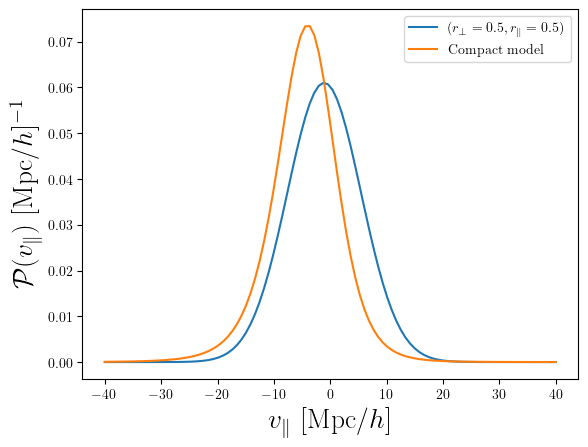

In [46]:
vlos = np.linspace(-40., 40.,100)

g_test = gaussian(vlos,r_perp=0.5,r_parallel=0.5)[0]
c_test = Pv_margM_vec_Mpc(vlos, 0.5, 0.5) #a*H*Pv_margM_vec(a*H*vlos, 0.5, 0.5)

plt.plot(vlos, g_test,
        label=r'$(r_\perp = 0.5, r_\parallel = 0.5)$')
plt.plot(vlos, c_test,
        label=r'Compact model')
plt.legend()
plt.ylabel(r'$\mathcal{P}(v_\parallel)$ [Mpc/$h]^{-1}$')
plt.xlabel(r'$v_\parallel$ [Mpc/$h]$')

print(np.sum(g_test), np.sum(c_test))

Text(0.5, 0, '$v_\\parallel$ [Mpc/$h]$')

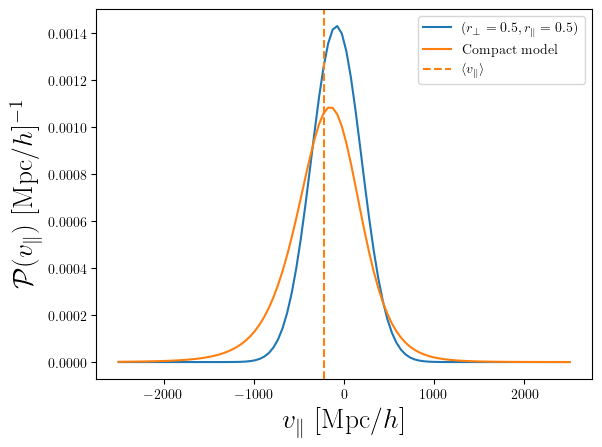

In [38]:
vlos = np.linspace(-2500,2500, 100)

R_test = 10
rlos_test = 10

plt.plot(vlos, (1/a/H)*gaussian(vlos/a/H,r_perp=R_test,r_parallel=rlos_test)[0],
        label=r'$(r_\perp = 0.5, r_\parallel = 0.5)$')
plt.plot(vlos, Pv_margM_vec(vlos, R_test, rlos_test),
        label=r'Compact model')
plt.axvline(vlos_mean(R_test, rlos_test, np.mean(mbins2)), c='C1', ls='--', label=r'$\langle v_\parallel \rangle$')
plt.legend()
plt.ylabel(r'$\mathcal{P}(v_\parallel)$ [Mpc/$h]^{-1}$')
plt.xlabel(r'$v_\parallel$ [Mpc/$h]$')

In [47]:
from scipy.interpolate import UnivariateSpline

compact_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins, 
    twopcf_function=UnivariateSpline(rbins_c,
                                     xigg_interp,s=0),
    los_pdf_function=Pv_margM_vec_Mpc,
)

In [46]:
compact_s_mu.shape

(59, 120)

In [19]:
s_mu_tpcf.shape

(59, 119)

In [48]:
compact_monopole = tpcf_multipole(
    compact_s_mu[:, :-1],
    mu_bins, 
    order=0
)
compact_quadrupole = tpcf_multipole(
    compact_s_mu[:, :-1], 
    mu_bins, 
    order=2
)
compact_hexadecapole = tpcf_multipole(
    compact_s_mu[:, :-1], 
    mu_bins, 
    order=4
)

In [55]:
gaussian_s_mu = simps_integrate(
    s_c=rbins_c, mu_c=mu_bins, 
    twopcf_function=UnivariateSpline(rbins_c,
                                     xigg_interp,s=0),
    los_pdf_function=gaussian,
)

gaussian_monopole = tpcf_multipole(
    gaussian_s_mu[:, :-1],
    mu_bins, 
    order=0
)
gaussian_quadrupole = tpcf_multipole(
    gaussian_s_mu[:, :-1], 
    mu_bins, 
    order=2
)
gaussian_hexadecapole = tpcf_multipole(
    gaussian_s_mu[:, :-1], 
    mu_bins, 
    order=4
)

In [56]:
print(monopole.shape, compact_monopole.shape, gaussian_monopole.shape)

(59,) (59,) (59,)


Text(0.5, 0, 'r [Mpc/h]')

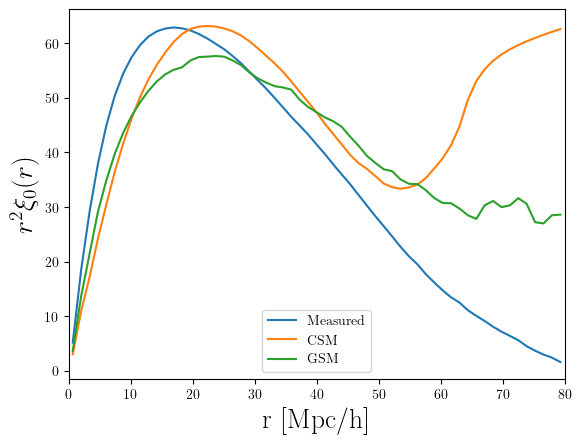

In [57]:
plt.plot(rbins_c, rbins_c**2*monopole,
       label='Measured')
plt.plot(rbins_c, rbins_c**2*compact_monopole,
        label='CSM')
plt.plot(rbins_c, rbins_c**2*gaussian_monopole,
        label='GSM')
plt.xlim(0,80) # if you want larger scales, extend the integration
# limit on simps integrate + extend UnivariateSpline limits 
# for moments and correlation function, remember it is an integral!
#plt.ylim(-200,150)
plt.legend()
plt.ylabel(r'$r^2\xi_0(r)$')
plt.xlabel('r [Mpc/h]')

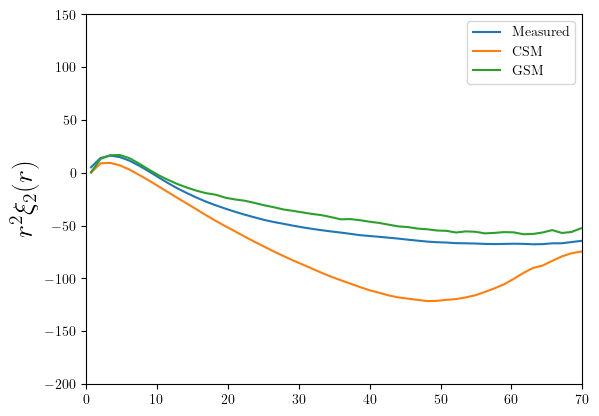

In [58]:
plt.plot(rbins_c, rbins_c**2*quadrupole,
        label='Measured')
plt.plot(rbins_c, rbins_c**2*compact_quadrupole,
        label='CSM')
plt.plot(rbins_c, rbins_c**2*gaussian_quadrupole,
        label='GSM')
plt.ylabel(r'$r^2\xi_2(r)$')

plt.xlim(0,70)
plt.ylim(-200,150)
plt.legend()

Text(0.5, 1.0, 'MDPL2 True Redshift-space $\\xi_{\\rm gg}(s, \\mu)$')

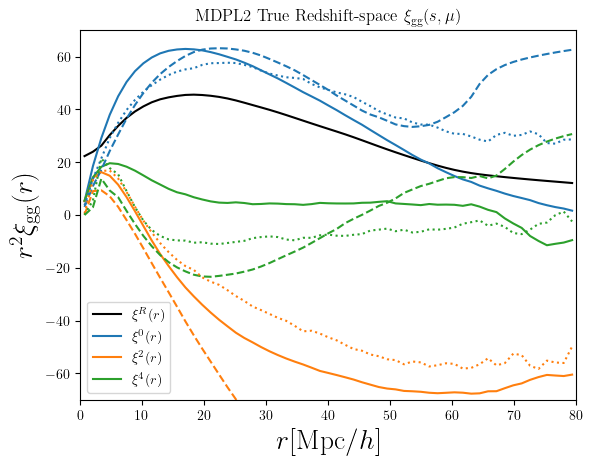

In [59]:

plt.plot(rbins_c, rbins_c**2*xigg_interp,
        label=r'$\xi^R(r)$', c='k')
plt.plot(rbins_c, rbins_c**2*monopole,
        label=r'$\xi^0(r)$')
plt.plot(rbins_c, rbins_c**2*quadrupole,
        label=r'$\xi^2(r)$')
plt.plot(rbins_c, rbins_c**2*hexadecapole,
        label=r'$\xi^4(r)$')

plt.plot(rbins_c, rbins_c**2*compact_monopole,
        ls='--', c='C0')
plt.plot(rbins_c, rbins_c**2*compact_quadrupole,
        ls='--', c='C1')
plt.plot(rbins_c, rbins_c**2*compact_hexadecapole,
        ls='--', c='C2')

plt.plot(rbins_c, rbins_c**2*gaussian_monopole,
        ls=':', c='C0')
plt.plot(rbins_c, rbins_c**2*gaussian_quadrupole,
        ls=':', c='C1')
plt.plot(rbins_c, rbins_c**2*gaussian_hexadecapole,
        ls=':', c='C2')


plt.legend()
plt.ylabel(r'$r^2\xi_{\rm gg}(r)$')
plt.xlabel(r'$r [\mathrm{Mpc}/h]$')

plt.xlim((0, 80))
plt.ylim((-70, 70))

plt.title(r'MDPL2 True Redshift-space $\xi_{\rm gg}(s, \mu)$')